In [22]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split

In [23]:
data = pd.read_csv('CARS.csv')

In [24]:
df = data.copy()

In [25]:
df = df[ df['co2_emissions'] < 431 ]
df = df[ df['co2_emissions'] > 110 ]

df = df.drop( ['make', 'model', 'year', 'vehicle_class', 'transmission', 'fuel_type', 'fuel_consumption', 'extra_field'], axis = 1 )

In [26]:
df.head()

,engine_size,cylinders,co2_emissions
0,2.5,4,180
1,1.8,4,150
2,2.5,4,135
3,3.5,6,235
4,4.0,6,320


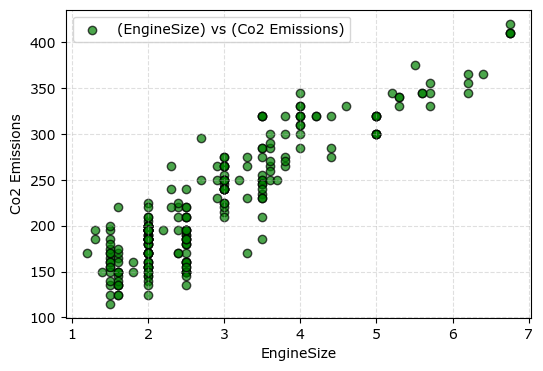

In [27]:
plt.figure( figsize = (6, 4) )

plt.scatter( df[['engine_size']], df[['co2_emissions']], color = 'g', edgecolor = 'k', alpha = 0.7, label = '(EngineSize) vs (Co2 Emissions)' )

plt.xlabel('EngineSize')
plt.ylabel('Co2 Emissions')

plt.grid(True, linestyle = '--', alpha = 0.4)

plt.legend()

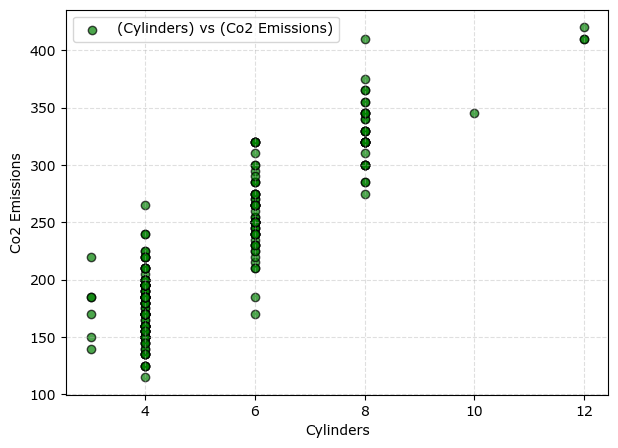

In [28]:
plt.figure( figsize = (7, 5) )

plt.scatter( df[['cylinders']], df[['co2_emissions']], color = 'g', edgecolor = 'k', alpha = 0.7, label = '(Cylinders) vs (Co2 Emissions)' )

plt.xlabel('Cylinders')
plt.ylabel('Co2 Emissions')

plt.grid(True, linestyle = '--', alpha = 0.4)

plt.legend()

In [29]:
x = df[[ 'engine_size', 'cylinders' ]]
y = df[[ 'co2_emissions' ]]

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 7)

print(f"\n           TRAIN    |    TEST\n\n\nX (Shape): {x_train.shape} | {x_test.shape}\n\nY (Shape): {y_train.shape} | {y_test.shape}\n")


           TRAIN    |    TEST


X (Shape): (172, 2) | (75, 2)

Y (Shape): (172, 1) | (75, 1)



In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_normalize = scaler.fit_transform(x_train)
x_test_normalize = scaler.transform(x_test)

In [32]:
regr = LinearRegression()

regr.fit(x_train_normalize, y_train)

print(f"\nCOEFFICIENTS: {regr.coef_[0][0]}    {regr.coef_[0][1]}\n\nINTERCEPT: {regr.intercept_[0]}\n")


COEFFICIENTS: 34.715980939211825    26.41730577497737

INTERCEPT: 219.65116279069767



In [33]:
pred = regr.predict(x_test_normalize)

print(f"\n1) r2_score: {r2_score(y_test, pred):1.3f}\n\n2) MSE: {mean_squared_error(y_test, pred):1.3f}\n\n3) MAE: {mean_absolute_error(pred, y_test):1.3f}\n")


1) r2_score: 0.871

2) MSE: 582.984

3) MAE: 18.398



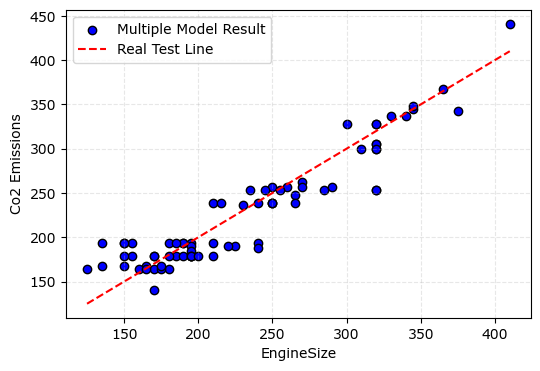

In [34]:
plt.figure( figsize = (6, 4) )

plt.scatter( y_test, pred, color = 'b', alpha = 1, edgecolor = 'k', label = 'Multiple Model Result' )

plt.plot( [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', label = 'Real Test Line' )

plt.xlabel('EngineSize')
plt.ylabel('Co2 Emissions')

plt.grid(True, linestyle = '--', alpha = 0.3)
plt.legend()